In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

In [3]:
df = pd.read_excel('Electric_Vehicle_Population_Cleaned_Data.xlsx')

In [4]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJSA1E22K,King,Seattle,WA,98112,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,43,202233958,POINT (-122.300312 47.629782),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033006500
1,3MW39FS05R,Yakima,Zillah,WA,98953,2024,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,15,264425178,POINT (-120.2658133 46.4063477),PACIFICORP,53077002201
2,1N4AZ0CP0F,King,Kent,WA,98031,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84,0,11,114962025,POINT (-122.201564 47.402358),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033029306
3,5YJSA1H20F,Snohomish,Bothell,WA,98012,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208,0,1,232724670,POINT (-122.206146 47.839957),PUGET SOUND ENERGY INC,53061052107
4,JTMAB3FV1N,Yakima,Yakima,WA,98908,2022,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42,0,14,221023589,POINT (-120.611068 46.596645),PACIFICORP,53077000902


### Analysis 1:

In [6]:
ev_adoption_by_year = df['Model Year'].value_counts().sort_index()

In [7]:
ev_adoption_by_year.head()

Model Year
1997    1
1998    1
1999    5
2000    7
2002    2
Name: count, dtype: int64

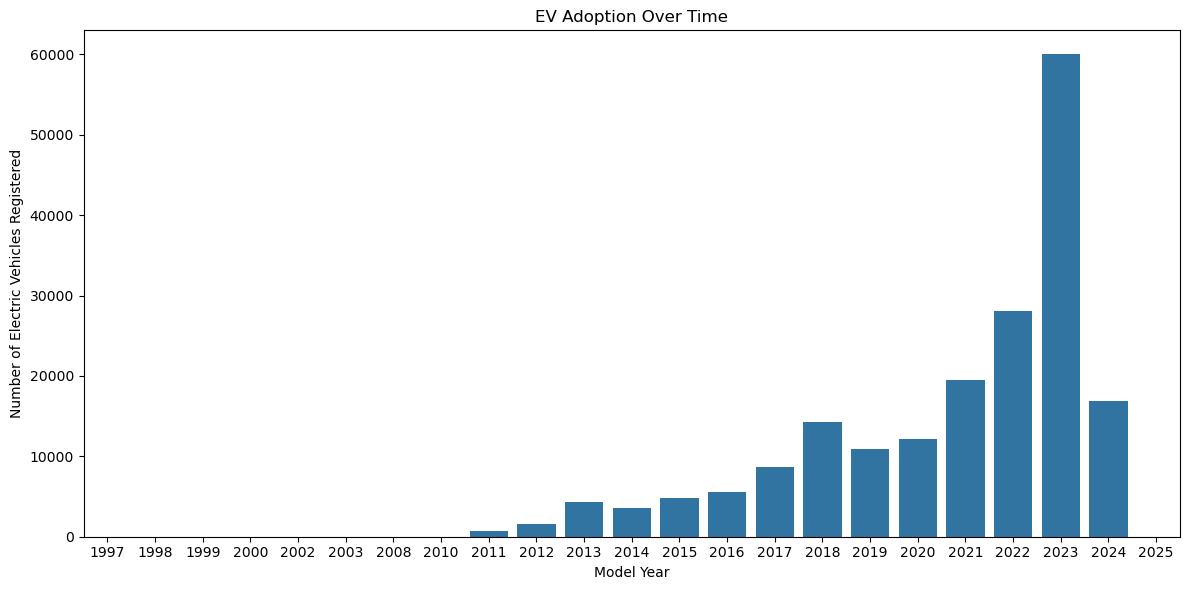

In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(x=ev_adoption_by_year.index, y=ev_adoption_by_year.values)
plt.title('EV Adoption Over Time')
plt.xlabel('Model Year')
plt.ylabel('Number of Electric Vehicles Registered')
plt.tight_layout()
plt.show()

### Analysis 2:

In [10]:
# geographical distribution at county level
ev_county_distribution = df['County'].value_counts()
top_counties = ev_county_distribution.head(3).index

In [11]:
top_counties

Index(['King', 'Snohomish', 'Pierce'], dtype='object', name='County')

In [12]:
# filtering the dataset for these top counties
top_counties_data = df[df['County'].isin(top_counties)]

In [13]:
top_counties_data.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJSA1E22K,King,Seattle,WA,98112,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,43,202233958,POINT (-122.300312 47.629782),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033006500
2,1N4AZ0CP0F,King,Kent,WA,98031,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84,0,11,114962025,POINT (-122.201564 47.402358),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033029306
3,5YJSA1H20F,Snohomish,Bothell,WA,98012,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208,0,1,232724670,POINT (-122.206146 47.839957),PUGET SOUND ENERGY INC,53061052107
5,5YJ3E1EB6K,King,Redmond,WA,98052,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220,0,48,296777442,POINT (-122.1207376 47.6705374),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033022606
8,5YJSA1E21H,King,Redmond,WA,98052,2017,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,45,241259105,POINT (-122.1207376 47.6705374),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032321


In [14]:
top_counties_data.shape

(136651, 17)

In [15]:
# analyzing the distribution of EVs within the cities of these top counties
ev_city_distribution_top_counties = top_counties_data.groupby(
    ['County', 'City']).size().sort_values(ascending=False).reset_index(
    name='Number of Vehicles')

In [16]:
ev_city_distribution_top_counties

,County,City,Number of Vehicles
0,King,Seattle,31436
1,King,Bellevue,9581
2,King,Redmond,6883
3,King,Kirkland,5709
4,King,Sammamish,5595
...,...,...,...
108,Snohomish,Shoreline,1
109,Snohomish,Startup,1
110,King,Gold Bar,1
111,Pierce,Prairie Ridge,1


In [17]:
# visualize the top 10 cities across these counties
top_cities = ev_city_distribution_top_counties.head(10)

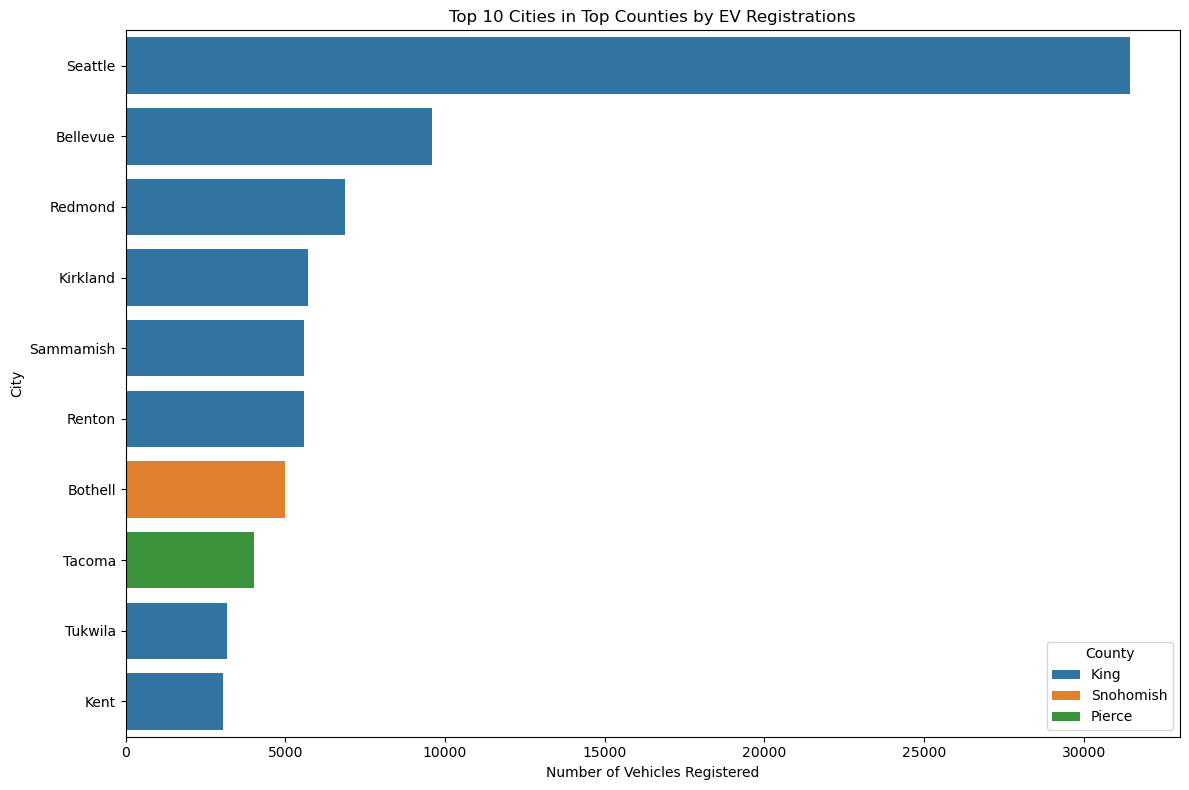

In [18]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Number of Vehicles', y='City', hue='County', data=top_cities)
plt.title('Top 10 Cities in Top Counties by EV Registrations')
plt.xlabel('Number of Vehicles Registered')
plt.ylabel('City')
plt.legend(title='County')
plt.tight_layout()
plt.show()

### Analysis 3:

In [20]:
ev_type_distribution = df['Electric Vehicle Type'].value_counts()

In [21]:
ev_type_distribution

Electric Vehicle Type
Battery Electric Vehicle (BEV)            149395
Plug-in Hybrid Electric Vehicle (PHEV)     41594
Name: count, dtype: int64

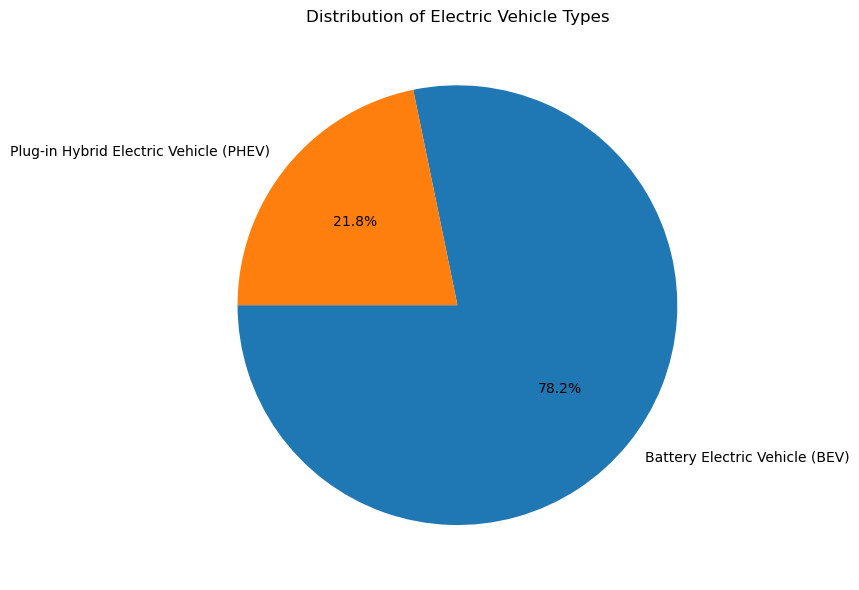

In [22]:
plt.figure(figsize=(12, 6))
plt.pie(ev_type_distribution.values, labels=ev_type_distribution.index, autopct='%1.1f%%', startangle=180)
plt.title('Distribution of Electric Vehicle Types')
plt.tight_layout()
plt.show()

### Analysis 4:

In [24]:
ev_make_distribution = df['Make'].value_counts().head(10)

In [25]:
ev_make_distribution

Make
TESLA         84464
CHEVROLET     14293
NISSAN        14225
FORD          10027
KIA            8657
BMW            7982
TOYOTA         7151
VOLKSWAGEN     5396
JEEP           4983
HYUNDAI        4969
Name: count, dtype: int64

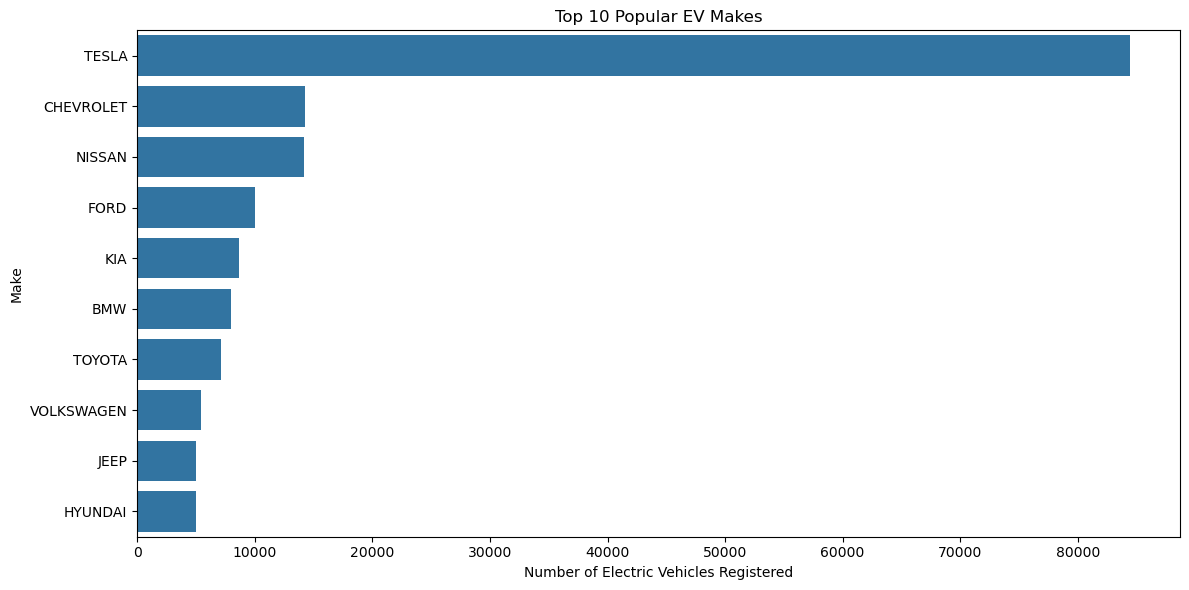

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(x=ev_make_distribution.values, y=ev_make_distribution.index)
plt.title('Top 10 Popular EV Makes')
plt.xlabel('Number of Electric Vehicles Registered')
plt.ylabel('Make')
plt.tight_layout()
plt.show()

In [27]:
# selecting the top 3 manufacturers based on the number of vehicles registered
top_3_makes = ev_make_distribution.head(3).index

In [28]:
top_3_makes

Index(['TESLA', 'CHEVROLET', 'NISSAN'], dtype='object', name='Make')

In [29]:
# filtering the dataset for these top manufacturers
top_makes_data = df[df['Make'].isin(top_3_makes)]

In [30]:
# analyzing the popularity of EV models within these top manufacturers
ev_model_distribution_top_makes = top_makes_data.groupby(
    ['Make', 'Model']).size().sort_values(ascending=False).reset_index(
    name='Number of Vehicles')

In [31]:
ev_model_distribution_top_makes

,Make,Model,Number of Vehicles
0,TESLA,MODEL Y,39443
1,TESLA,MODEL 3,30884
2,NISSAN,LEAF,13425
3,TESLA,MODEL S,7848
4,CHEVROLET,BOLT EV,6433
5,TESLA,MODEL X,6113
6,CHEVROLET,VOLT,4789
7,CHEVROLET,BOLT EUV,2646
8,NISSAN,ARIYA,800
9,CHEVROLET,SPARK,246


In [32]:
# visualizing the top 10 models across these manufacturers for clarity
top_models = ev_model_distribution_top_makes.head(10)

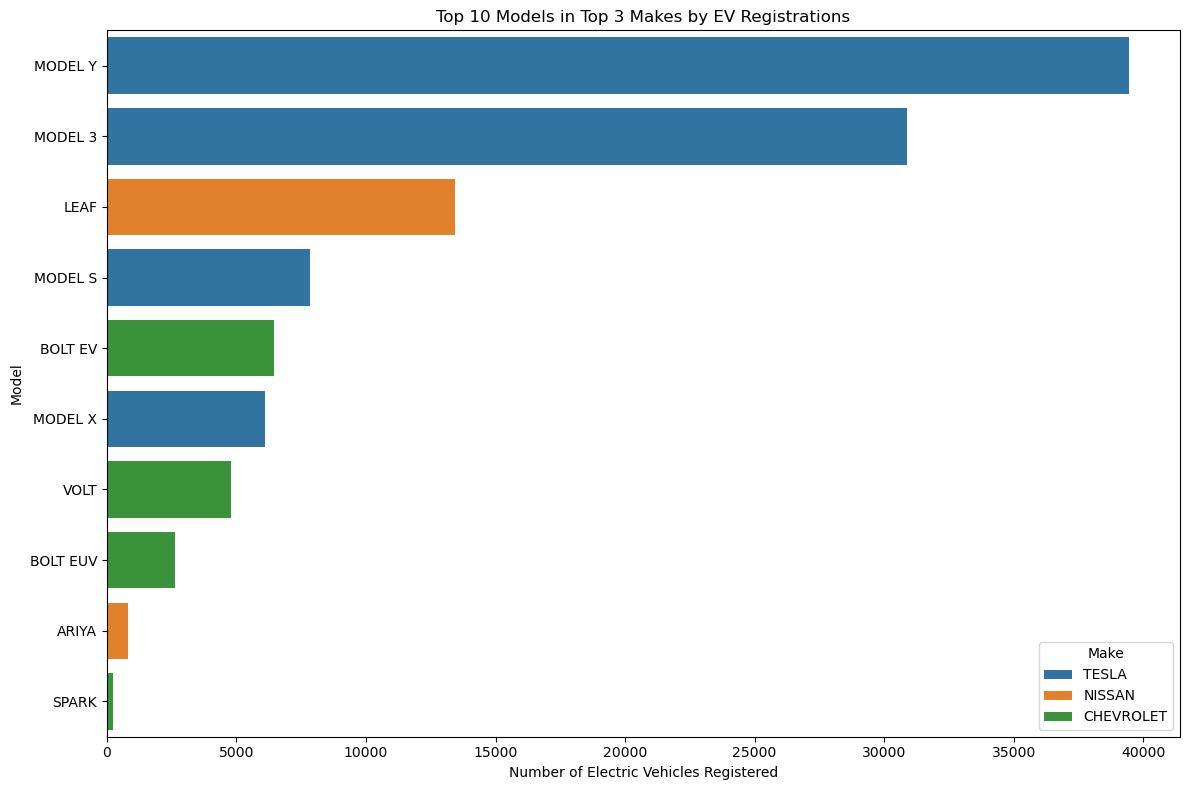

In [33]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Number of Vehicles', y='Model', hue='Make', data=top_models)
plt.title('Top 10 Models in Top 3 Makes by EV Registrations')
plt.xlabel('Number of Electric Vehicles Registered')
plt.ylabel('Model')
plt.legend(title='Make')
plt.tight_layout()
plt.show()

### Analysis 5:

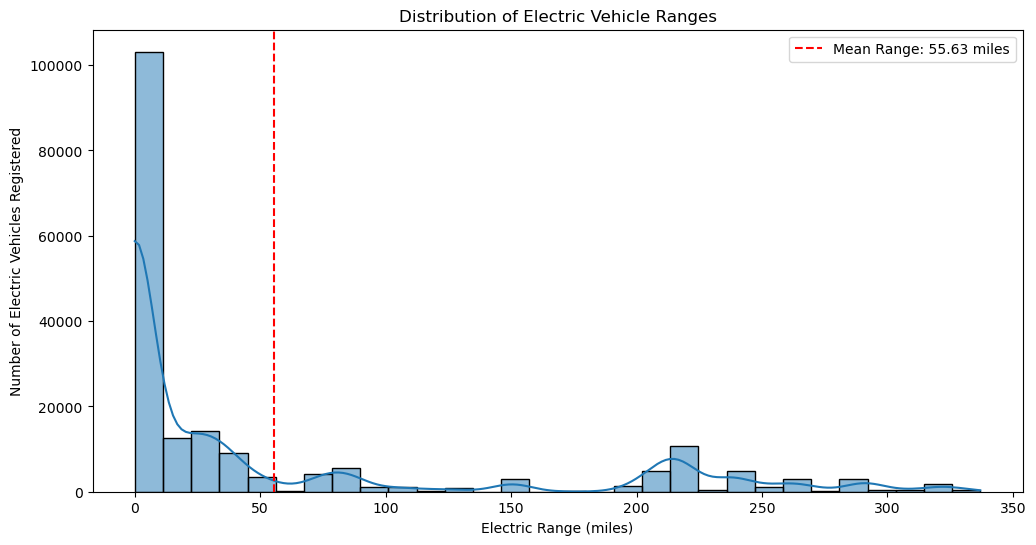

In [35]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Electric Range'], bins=30, kde=True)
plt.title('Distribution of Electric Vehicle Ranges')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Number of Electric Vehicles Registered')

# Mean Line
plt.axvline(df['Electric Range'].mean(), color='red', linestyle='--', 
            label=f'Mean Range: {df["Electric Range"].mean():.2f} miles')
plt.legend()
plt.show()

In [36]:
# calculating the average electric range by model year
average_range_by_year = df.groupby('Model Year')['Electric Range'].mean().reset_index()

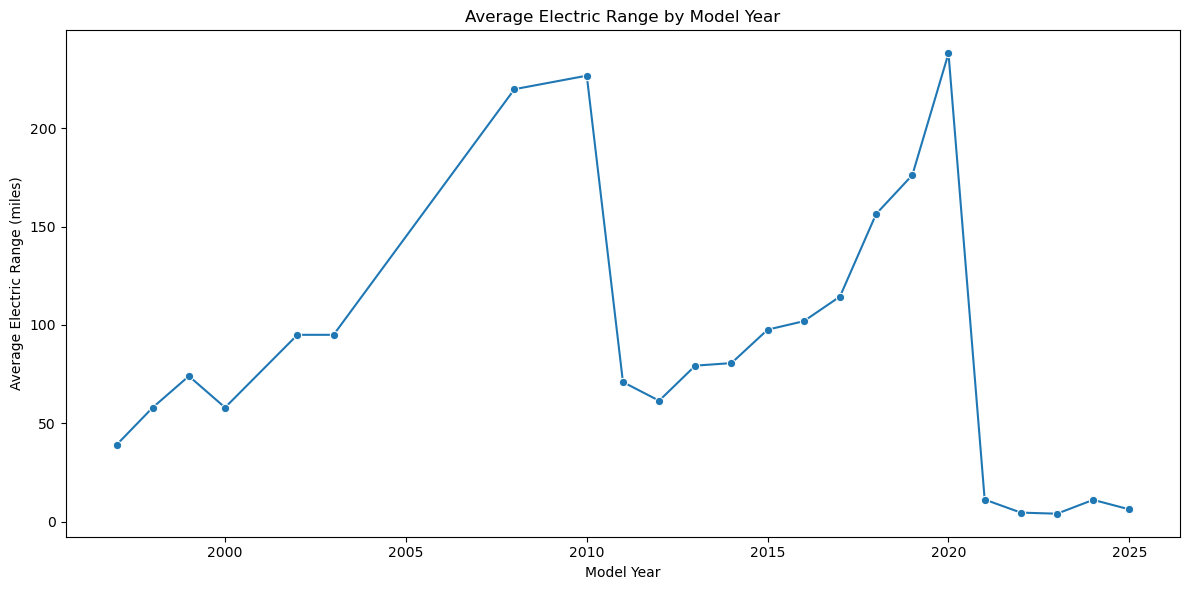

In [37]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Model Year', y='Electric Range', data=average_range_by_year, marker='o')
plt.title('Average Electric Range by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Average Electric Range (miles)')
plt.tight_layout()
plt.show()

In [38]:
average_range_by_model = top_makes_data.groupby(
    ['Make', 'Model'])['Electric Range'].mean().sort_values(
    ascending=False).reset_index()

In [39]:
# the top 10 models with the highest average electric range
top_range_models = average_range_by_model.head(10)

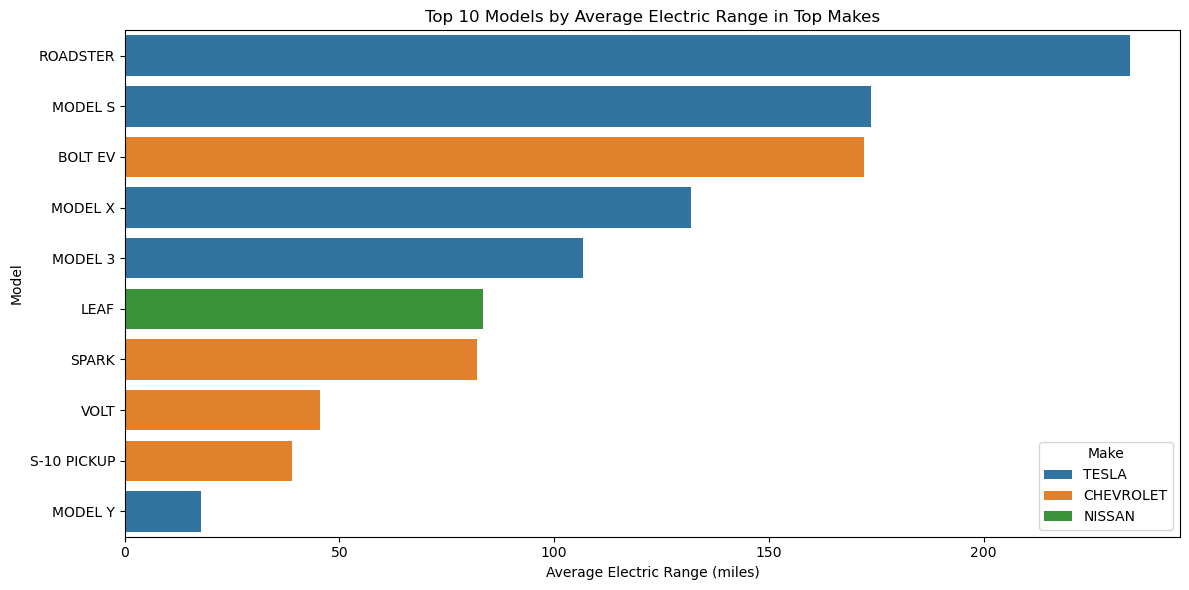

In [40]:
plt.figure(figsize=(12, 6))
barplot = sns.barplot(x='Electric Range', y='Model', hue='Make', data=top_range_models)
plt.title('Top 10 Models by Average Electric Range in Top Makes')
plt.xlabel('Average Electric Range (miles)')
plt.ylabel('Model')
plt.legend(title='Make')
plt.tight_layout()
plt.show()

### Analysis 6:

In [42]:
# calculate the number of EVs registered each year
ev_registration_counts = df['Model Year'].value_counts().sort_index()

In [43]:
ev_registration_counts

Model Year
1997        1
1998        1
1999        5
2000        7
2002        2
2003        1
2008       21
2010       24
2011      736
2012     1592
2013     4356
2014     3521
2015     4802
2016     5517
2017     8625
2018    14303
2019    10902
2020    12112
2021    19462
2022    28045
2023    60004
2024    16944
2025        6
Name: count, dtype: int64

In [44]:
# filter the dataset to include years with complete data, assuming 2023 is the last complete year
filtered_years = ev_registration_counts[ev_registration_counts.index <= 2023]

In [45]:
filtered_years

Model Year
1997        1
1998        1
1999        5
2000        7
2002        2
2003        1
2008       21
2010       24
2011      736
2012     1592
2013     4356
2014     3521
2015     4802
2016     5517
2017     8625
2018    14303
2019    10902
2020    12112
2021    19462
2022    28045
2023    60004
Name: count, dtype: int64

In [46]:
# define a function for exponential growth to fit the data
def exp_growth(x, a, b):
    return a * np.exp(b * x)

In [47]:
# prepare the data for curve fitting
x_data = filtered_years.index - filtered_years.index.min()
y_data = filtered_years.values

In [48]:
# fit the data to the exponential growth function
params, covariance = curve_fit(exp_growth, x_data, y_data)

In [49]:
# use the fitted function to forecast the number of EVs for 2024 and the next five years
forecast_years = np.arange(2024, 2024 + 6) - filtered_years.index.min()
forecasted_values = exp_growth(forecast_years, *params)

In [50]:
forecasted_values

array([ 84076.42350155, 129363.70474366, 199044.7191738 , 306259.01066673,
       471223.66272209, 725045.57441693])

In [51]:
# create a dictionary to display the forecasted values for easier interpretation
forecasted_evs = dict(zip(forecast_years + filtered_years.index.min(), forecasted_values))

In [52]:
# prepare data for plotting
years = np.arange(filtered_years.index.min(), 2029 + 1)
actual_years = filtered_years.index
forecast_years_full = np.arange(2024, 2029 + 1)

In [53]:
# actual and forecasted values
actual_values = filtered_years.values
forecasted_values_full = [forecasted_evs[year] for year in forecast_years_full]

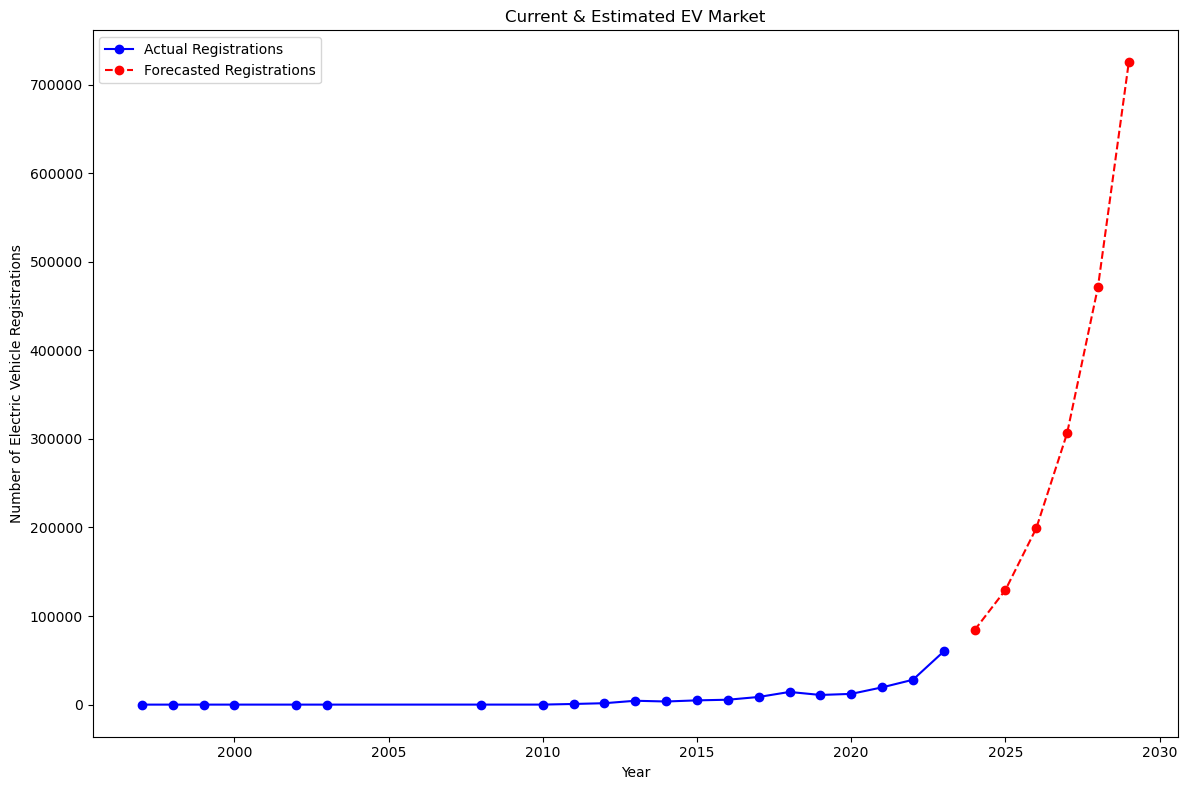

In [54]:
plt.figure(figsize=(12, 8))
plt.plot(actual_years, actual_values, 'bo-', label='Actual Registrations')
plt.plot(forecast_years_full, forecasted_values_full, 'ro--', label='Forecasted Registrations')
plt.title('Current & Estimated EV Market')
plt.xlabel('Year')
plt.ylabel('Number of Electric Vehicle Registrations')
plt.legend()
plt.tight_layout()
plt.show()